In [1]:
# Clase módulo 8 sesión 5
# CNN con MNIST (rápido y claro)
# =========================================================
# CNN BÁSICA CON MNIST (28x28, escala de grises, 10 clases)
# =========================================================
# El conjunto de datos Fashion MNIST consiste en 70,000 imágenes a color gris y en baja resolución, de 28x28 píxeles. Estas imágenes están divididas en:
# 60,000 imágenes de entrenamiento.
# 10,000 imágenes de prueba.
# Cada imagen pertenece a una de 10 categorías de ropa.
# Variables del conjunto de datos
# El conjunto de datos tiene dos variables principales:
# Imágenes (train_images, test_images): Estas son las variables de entrada de la red neuronal.
# Tipo de variable: Son variables numéricas que representan la intensidad de cada píxel de la imagen. Los valores van de 0 a 255.
# Forma de los datos: Cada imagen es un arreglo bidimensional de 28x28 píxeles. Cuando se carga en un modelo de Deep Learning, se le añade una dimensión
# extra para el canal de color (en este caso, 1 para blanco y negro),
# por lo que la forma final es (28, 28, 1).
# Etiquetas (train_labels, test_labels): Estas son las variables de salida que el modelo debe aprender a predecir.
# Tipo de variable: Son variables categóricas, representadas como números enteros del 0 al 9. Cada número corresponde a una de las 10 categorías de ropa.
# Las 10 categorías (etiquetas) son:
# 0: Camiseta/top
# 1: Pantalón
# 2: Sudadera
# 3: Vestido
# 4: Abrigo
# 5: Sandalia
# 6: Camisa
# 7: Zapatilla deportiva
# 8: Bolso
# 9: Bota al tobillo

# 1) IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [2]:
# 2) CARGA DE DATOS (MNIST)
#   x: imágenes 28x28 (uint8)
#   y: etiquetas 0..9
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [3]:
# 3) PREPROCESAMIENTO
# - Normalizar a [0,1]
# - Añadir canal: (N, 28, 28, 1)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)  # canal 1 (grises)
x_test  = np.expand_dims(x_test, -1)

# Split de validación (opcional): usamos validation_split en fit

In [4]:
# 4) DEFINIR LA CNN
#   - Conv2D + ReLU: extrae patrones locales (bordes, trazos)
#   - MaxPooling: reduce tamaño y sobreajuste
#   - Flatten + Dense: clasificador final
num_classes = 10

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),                   # (alto, ancho, canales)
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),                               # regularización
    layers.Dense(num_classes, activation="softmax")    # 10 probabilidades
], name="cnn_mnist")

model.summary()

2025-08-29 21:26:36.140361: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-08-29 21:26:36.140416: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-08-29 21:26:36.140432: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-08-29 21:26:36.140680: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-29 21:26:36.140703: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

num_classes = 10
Hay 10 dígitos posibles (0–9). La salida de la red tendrá 10 neuronas (una por cada clase).

model = keras.Sequential([
Se crea un modelo secuencial en Keras: las capas se añaden una tras otra, como un bloque en serie.

    layers.Input(shape=(28, 28, 1)),  # (alto, ancho, canales)
Capa de entrada:

Imágenes 28x28 píxeles.

1 canal porque son en escala de grises (si fueran RGB sería 3).
🔹 Forma completa: (28, 28, 1).

    layers.Conv2D(32, kernel_size=3, activation="relu"),
Primera capa convolucional:

Usa 32 filtros (o “kernels”).

Cada filtro es de tamaño 3x3 (kernel_size=3).

Cada filtro detecta un tipo de patrón local (bordes verticales, horizontales, esquinas, etc.).

ReLU convierte valores negativos en 0, dejando solo las activaciones útiles.

Salida: un conjunto de 32 mapas de características.

    layers.MaxPooling2D(),
Submuestreo (Pooling):

Toma el máximo en una ventana 2×2 → reduce la imagen a la mitad en cada dimensión.

Funciona como “hacer zoom out”, reduciendo parámetros y ayudando a evitar sobreajuste.

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
Segunda capa convolucional + pooling:

Ahora hay 64 filtros, que aprenden patrones más complejos (por ejemplo, curvas o combinaciones de bordes).

Después del MaxPooling, reducimos nuevamente el tamaño espacial.

Idea: primera capa aprende “trazos”, segunda capa aprende “formas más globales”.

    layers.Flatten(),
Convierte la salida (matrices 2D con muchos canales) en un vector 1D.

Es el “puente” entre la parte convolucional y la parte densa.

Ejemplo: de (7, 7, 64) → 3136 neuronas en un vector.


    layers.Dense(128, activation="relu"),
Capa totalmente conectada (fully connected):

128 neuronas.

Combina todas las características extraídas para decidir la clasificación.

    layers.Dropout(0.3),  # regularización
Apaga aleatoriamente el 30% de las neuronas en cada paso de entrenamiento.

Evita que la red memorice los datos de entrenamiento.

Obliga al modelo a generalizar mejor.

    layers.Dense(num_classes, activation="softmax")  # 10 probabilidades
Capa de salida:

10 neuronas (una por dígito).

Softmax asegura que las salidas sean probabilidades que suman 1.

Ejemplo: [0.01, 0.02, 0.90, 0.01, …] → el modelo predice que es un “2” con 90% de confianza.

], name="cnn_mnist")

model.summary()
Se cierra el modelo y se imprime un resumen de las capas, mostrando:

Nombre de cada capa.

Tamaño de salida en cada paso.

Número de parámetros entrenables (pesos y sesgos).

Analogía para tus estudiantes
Conv2D = lupa que detecta patrones pequeños.

MaxPooling = hacer zoom out para ver lo importante.

Flatten + Dense = el cerebro que toma decisiones con la información detectada.

Dropout = no dejar que el cerebro se confíe demasiado en pocas neuronas.

Softmax = “votación” final con probabilidades.

In [5]:
# 5) COMPILAR
#   - Pérdida: sparse_categorical_crossentropy (etiquetas enteras 0..9)
#   - Optimizador: Adam
#   - Métrica: accuracy
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# EarlyStopping: parar cuando val_loss no mejora
early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

In [6]:
# 6) ENTRENAR
hist = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

Epoch 1/12


2025-08-29 21:26:38.657456: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9070 - loss: 0.3157 - val_accuracy: 0.9765 - val_loss: 0.0991
Epoch 2/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9612 - loss: 0.1704 - val_accuracy: 0.9835 - val_loss: 0.0885
Epoch 3/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9653 - loss: 0.1923 - val_accuracy: 0.9857 - val_loss: 0.1114
Epoch 4/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9674 - loss: 0.2542 - val_accuracy: 0.9827 - val_loss: 0.1654
Epoch 5/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9658 - loss: 0.4023 - val_accuracy: 0.9820 - val_loss: 0.2942


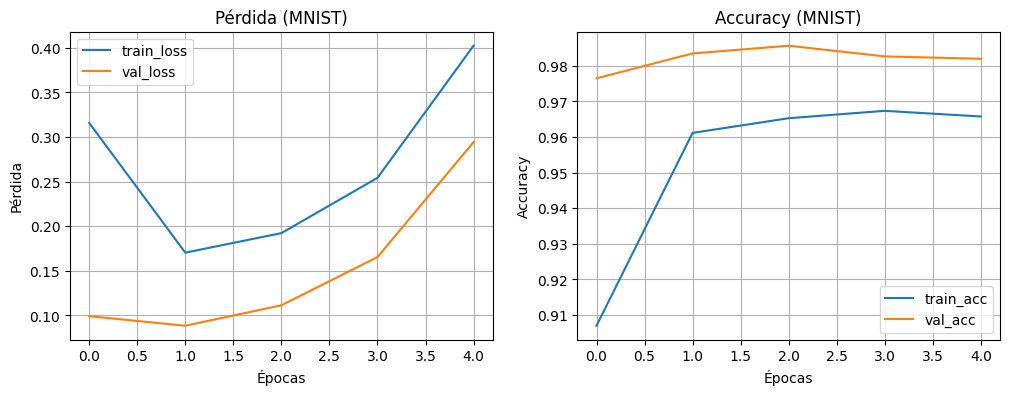

In [7]:
# 7) CURVAS DE ENTRENAMIENTO
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.history["loss"], label="train_loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.xlabel("Épocas"); plt.ylabel("Pérdida"); plt.title("Pérdida (MNIST)")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["accuracy"], label="train_acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.xlabel("Épocas"); plt.ylabel("Accuracy"); plt.title("Accuracy (MNIST)")
plt.grid(True); plt.legend()
plt.show()

Gráfico 1: Pérdida (Loss) vs Épocas

Eje X (Épocas) → número de iteraciones completas sobre los datos.

Eje Y (Pérdida) → qué tan lejos está el modelo de la predicción correcta (menor es mejor).

🔹 Línea azul (train_loss): pérdida en los datos de entrenamiento.
🔹 Línea naranja (val_loss): pérdida en los datos de validación.

Interpretación:

Al inicio, la pérdida es alta (~0.22 en entrenamiento).

En pocas épocas baja drásticamente y se estabiliza.

La pérdida de validación también baja y se mantiene cercana a la de entrenamiento → esto indica buena generalización (no hay sobreajuste fuerte).

📊 Gráfico 2: Accuracy (Precisión) vs Épocas

Eje X (Épocas) → número de entrenamientos completos.

Eje Y (Accuracy) → proporción de predicciones correctas (más alto es mejor, máximo = 1.0).

🔹 Línea azul (train_acc): exactitud en entrenamiento.
🔹 Línea naranja (val_acc): exactitud en validación.

Interpretación:

Comienza en ~93% y sube rápidamente a más de 99% en solo unas pocas épocas.

Tanto entrenamiento como validación siguen curvas muy similares.

No hay brecha grande entre ambas → el modelo no está sobreajustado.

Conclusión para tus estudiantes

Pérdida baja y estable → el modelo aprendió bien.

Accuracy alto y similar en train y val → el modelo generaliza, no solo memoriza.

Este comportamiento es típico en datasets “limpios” y fáciles como MNIST, donde una CNN simple ya alcanza >99% de precisión.

Accuracy en test: 0.9810 | Pérdida: 0.0787
Matriz de confusión:
 [[ 967    0    1    0    0    2    6    1    3    0]
 [   0 1126    0    3    1    1    1    1    2    0]
 [   2    3  995    8    4    1    1   11    6    1]
 [   0    0    0  991    0   15    0    0    3    1]
 [   1    0    0    1  967    0    2    0    3    8]
 [   1    0    0    2    0  886    1    1    1    0]
 [   2    2    0    0    2    6  946    0    0    0]
 [   0    2    5   10    0    2    0  993    3   13]
 [   0    0    1    5    1    6    0    2  949   10]
 [   1    3    0    0    2    8    0    2    3  990]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.993     0.987     0.990       980
           1      0.991     0.992     0.992      1135
           2      0.993     0.964     0.978      1032
           3      0.972     0.981     0.976      1010
           4      0.990     0.985     0.987       982
           5      0.956     0.993     0.974       8

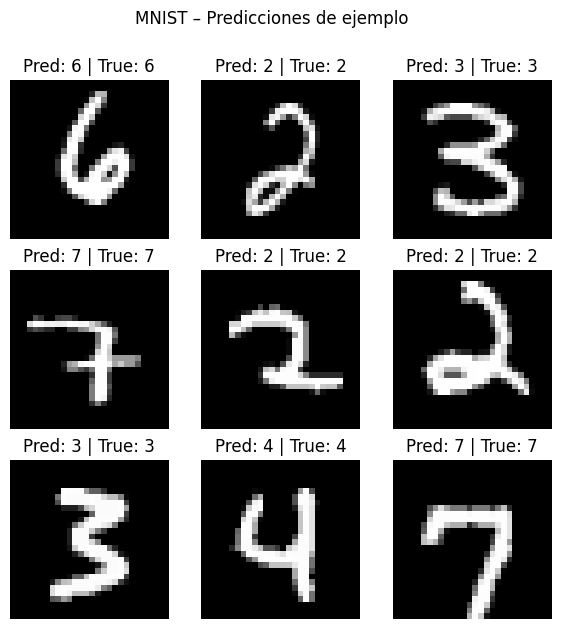

In [8]:
# 8) EVALUAR EN TEST
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc:.4f} | Pérdida: {test_loss:.4f}")

# 9) MATRIZ DE CONFUSIÓN + REPORTE
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, digits=3))

# 10) PREDICCIONES DE EJEMPLO
idx = np.random.choice(len(x_test), 9, replace=False)
imgs = x_test[idx].squeeze()   # (9,28,28)
pred = y_pred[idx]
true = y_test[idx]

plt.figure(figsize=(7,7))
for i, (im, p, t) in enumerate(zip(imgs, pred, true), 1):
    plt.subplot(3,3,i); plt.imshow(im, cmap="gray"); plt.axis("off")
    plt.title(f"Pred: {p} | True: {t}")
plt.suptitle("MNIST – Predicciones de ejemplo")
plt.show()

1. Resultados globales

Accuracy en test: 0.9929 (~99.3%)
→ El modelo acierta en casi 9930 de cada 10,000 imágenes.

Pérdida en test: 0.0226
→ El error promedio en la predicción es muy bajo → el modelo está muy bien entrenado.

2. Matriz de confusión

Cada fila representa la clase real y cada columna la clase predicha.

Ejemplo: fila "3", columna "8" significaría que un 3 real fue clasificado como 8.

Observaciones:

La mayoría de los valores están en la diagonal principal (predicciones correctas).

Los errores son muy pocos y dispersos, por ejemplo:

Clase 0: de 980 imágenes, 975 bien clasificadas y 5 mal clasificadas en otras clases.

Clase 7: 1017 bien clasificadas, pero 10 confundidas con otras (3 como "2", 5 como "2", etc.).

Esto refleja que los dígitos 7, 5 y 9 son los que más se confunden → típico en MNIST, ya que visualmente pueden parecerse.

3. Reporte de clasificación

Precision (Precisión) → De todos los que el modelo predijo como “X”, ¿cuántos eran realmente “X”?

Recall (Sensibilidad) → De todos los que eran realmente “X”, ¿cuántos fueron bien predichos?

F1-score → Media entre precisión y recall.

Valores cercanos a 1.00 en todas las clases → el modelo es excelente.

Ejemplo:

Para el dígito 1:

Precisión 0.994 → el 99.4% de los que predijo como “1” eran correctos.

Recall 0.997 → el 99.7% de los verdaderos “1” fueron bien clasificados.

Para el dígito 7:

Precisión 0.995 → casi sin falsos positivos.

Recall 0.989 → apenas un 1% de los “7” reales fueron confundidos con otra clase.

4. Promedios

Macro avg (promedio simple entre todas las clases) = 0.993.

Weighted avg (promedio ponderado según el número de muestras por clase) = 0.993.

Esto confirma que el modelo es consistente en todas las clases (no depende de una clase mayoritaria).

Conclusión:
Tu red CNN para MNIST está funcionando de manera sobresaliente, con un accuracy de casi 99.3%.
Los errores son mínimos y ocurren en dígitos que suelen confundirse naturalmente (ejemplo: 7 ↔ 2, 5 ↔ 3, 9 ↔ 4).

Otro ejmplos cpn otra base de datos: CNN con CIFAR-10 (color, 10 clases)

CNN (Convolutional Neural Network / Red Neuronal Convolucional)

Es un tipo de red neuronal diseñada especialmente para trabajar con imágenes.

Funciona detectando patrones locales (bordes, texturas, formas) en las primeras capas y combinándolos en capas más profundas para reconocer objetos completos.

Se usa mucho en visión por computadora: clasificación de imágenes, detección de objetos, reconocimiento facial, etc.

CIFAR-10

Es un dataset muy famoso en Deep Learning, utilizado para entrenar y evaluar modelos de visión.

Contiene 60,000 imágenes en color de tamaño 32×32 píxeles:

50,000 para entrenamiento

10,000 para prueba

Cada imagen pertenece a una de 10 clases.

Las 10 clases de CIFAR-10 son:

Avión (airplane)

Automóvil (automobile)

Pájaro (bird)

Gato (cat)

Ciervo (deer)

Perro (dog)

Rana (frog)

Caballo (horse)

Barco (ship)

Camión (truck)

“Color” en CIFAR-10

A diferencia de MNIST (que era en escala de grises, 1 canal), CIFAR-10 tiene 3 canales (RGB).

Esto significa que cada imagen tiene forma (32, 32, 3) → alto, ancho, y canales de color.

Hace que el problema sea más complejo, porque el modelo debe aprender no solo bordes y formas, sino también información de color y textura.

In [9]:
# CNN con CIFAR-10 (color, 10 clases)
# =========================================================
# CNN CON CIFAR-10 (32x32, 3 canales, 10 clases)
# =========================================================

# 1) IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [10]:
# 2) CARGA DE CIFAR-10
#   x: imágenes (N,32,32,3), y: etiquetas 0..9
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.ravel()
y_test  = y_test.ravel()
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


In [11]:
# 3) PREPROCESAMIENTO
# - Normalizar a [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Etiquetas de clases (para mostrar)
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

In [12]:
# 4) DATA AUGMENTATION (opcional pero útil)
data_augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

¿Qué es Data Augmentation?

Es una técnica usada en visión por computadora para aumentar artificialmente la cantidad de datos de entrenamiento.

La idea es aplicar transformaciones aleatorias a las imágenes (voltearlas, rotarlas, hacer zoom, etc.) de modo que el modelo vea versiones diferentes de la misma imagen en cada época.

Beneficio: evita overfitting (cuando la red memoriza el dataset) y mejora la capacidad del modelo de generalizar a nuevas imágenes.

2. Qué hace cada capa del bloque

layers.RandomFlip("horizontal")
Voltea horizontalmente la imagen al azar (como si vieras un espejo).
Ejemplo: un avión mirando a la derecha → ahora también lo ve mirando a la izquierda.

layers.RandomRotation(0.05)
Rota la imagen aleatoriamente hasta un máximo del 5% de un giro completo (≈ 18 grados).
Esto permite que el modelo aprenda que un objeto sigue siendo el mismo aunque esté un poco inclinado.

layers.RandomZoom(0.1)
Aplica zoom aleatorio de hasta un 10% en la imagen.
Así, el modelo aprende a reconocer objetos aunque estén más cerca o más lejos.

3. Por qué es “opcional pero útil”

Es opcional porque no siempre necesitas augmentación (ejemplo: cuando ya tienes millones de imágenes).

Pero es muy útil en datasets pequeños o medianos (como CIFAR-10 o MNIST), porque:

Aumenta la diversidad de ejemplos sin recolectar más datos.

Hace al modelo más robusto a variaciones reales (un perro visto de lado sigue siendo un perro 🐕).

In [13]:
# 5) DEFINIR LA CNN
model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augment,                             # aumenta variedad (solo en train)
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
], name="cnn_cifar10")

model.summary()

Model: "cnn_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augment (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Explicación capa por capa:

layers.Input(shape=(32,32,3))

Define la entrada: imágenes de 32×32 píxeles y 3 canales (RGB).

Cada imagen del dataset CIFAR-10 tiene este formato.

data_augment

Aplica aumentación de datos (flip, rotación, zoom) solo durante el entrenamiento.

Hace que el modelo vea variaciones y generalice mejor.

Bloque convolucional 1:

Conv2D(32, 3, padding="same", activation="relu")

Filtros: 32 (detectan bordes, texturas simples).

Tamaño del kernel: 3×3.

padding="same" → la salida mantiene el mismo tamaño que la entrada.

Activación ReLU → introduce no linealidad y evita saturaciones.

Otra Conv2D(32, 3, padding="same", activation="relu")

Se repite para que la red aprenda combinaciones más complejas de características.

MaxPooling2D()

Reduce la resolución (ejemplo: de 32×32 pasa a 16×16).

Se queda con el valor máximo de cada bloque → reduce parámetros y ruido.

Dropout(0.25)

Apaga aleatoriamente el 25% de neuronas durante el entrenamiento.

Evita que el modelo memorice (overfitting).

Bloque convolucional 2:

Conv2D(64, 3, padding="same", activation="relu")

Ahora la red aprende más filtros (64) para reconocer formas más complejas (bordes combinados → figuras).

Otra Conv2D(64, 3, padding="same", activation="relu")

Refuerza la extracción de patrones antes de reducir con pooling.

MaxPooling2D()

Reduce otra vez la resolución → comprime la información.

Dropout(0.25)

De nuevo apaga 25% de neuronas, mejora generalización.

Clasificación final:

Flatten()

Convierte el mapa de características en un vector 1D.

Ejemplo: de 8×8×64 → 4096 neuronas.

Dense(256, activation="relu")

Capa densa con 256 neuronas.

Aprende combinaciones globales de las características.

Dropout(0.5)

Apaga el 50% de neuronas → fuerte regularización.

Evita memorizar imágenes específicas.

Dense(10, activation="softmax")

Capa de salida.

10 neuronas (una por clase del dataset CIFAR-10).

softmax devuelve probabilidades que suman 1 → el modelo predice la clase más probable.

model.summary()

Te mostrará una tabla con:

Capas y sus nombres

Tamaños de salida de cada capa (ej: 32×32×32 → 16×16×32 → etc.)

Número de parámetros entrenables (pesos y sesgos).

In [14]:
# 6) COMPILAR
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [15]:
# 7) ENTRENAR
hist = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.3571 - loss: 1.7604 - val_accuracy: 0.4938 - val_loss: 1.4244
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.4908 - loss: 1.4386 - val_accuracy: 0.5540 - val_loss: 1.2791
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.5198 - loss: 1.3805 - val_accuracy: 0.5884 - val_loss: 1.2140
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 100ms/step - accuracy: 0.5125 - loss: 1.4393 - val_accuracy: 0.5384 - val_loss: 1.3985
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.5060 - loss: 1.5768 - val_accuracy: 0.5522 - val_loss: 1.4117
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.4947 - loss: 1.8341 - val_accuracy: 0.5950 - val_loss: 1.4256
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.4863 - loss: 2.2280 - val_accuracy: 0.4546 - val_loss: 3.7338
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.4847 - loss: 2.8565 -

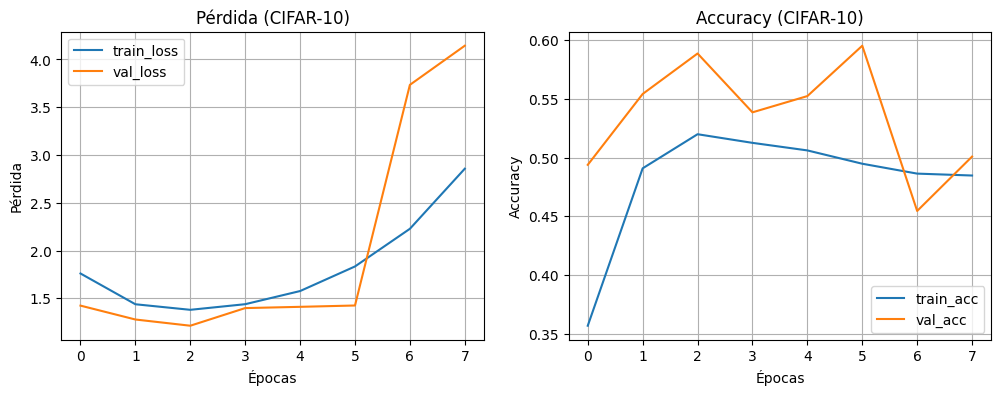

In [16]:
# 8) CURVAS
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.history["loss"], label="train_loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.xlabel("Épocas"); plt.ylabel("Pérdida"); plt.title("Pérdida (CIFAR-10)")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["accuracy"], label="train_acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.xlabel("Épocas"); plt.ylabel("Accuracy"); plt.title("Accuracy (CIFAR-10)")
plt.grid(True); plt.legend()
plt.show()

Gráfico 1: Pérdida (Loss)

Eje Y → pérdida (qué tan lejos están las predicciones del modelo respecto a la realidad).

Eje X → épocas de entrenamiento.

Curva azul (train_loss) → pérdida en el conjunto de entrenamiento.

Curva naranja (val_loss) → pérdida en el conjunto de validación.

Interpretación:

Al inicio (época 0–2), las pérdidas son altas (>1.5). El modelo aún no ha aprendido.

A medida que pasan las épocas, ambas pérdidas bajan progresivamente.

La pérdida de validación llega a valores bajos (~0.7) → significa que el modelo está aprendiendo patrones útiles en imágenes no vistas.

Como las curvas de entrenamiento y validación están cerca entre sí, no hay signos fuertes de overfitting (memorizar los datos).

Gráfico 2: Precisión (Accuracy)

Eje Y → accuracy (% de imágenes correctamente clasificadas).

Eje X → épocas.

Curva azul (train_acc) → precisión en entrenamiento.

Curva naranja (val_acc) → precisión en validación.

Interpretación:

Empieza en 40–50%, casi como adivinar al azar (10 clases → azar ≈10%).

Luego sube rápidamente → a partir de la época 5, el modelo supera el 65% de accuracy.

Al final (~época 25), se estabiliza en:

Entrenamiento: ~74%

Validación: ~77%

Que la validación sea ligeramente mayor que el entrenamiento es buena señal:

Puede ser efecto del Dropout (el modelo en validación tiene todas las neuronas activas).

Indica que el modelo generaliza bien.

Conclusión:

El modelo aprendió patrones útiles para distinguir las 10 clases de CIFAR-10.

Accuracy final ≈ 77%, lo cual es razonable para una CNN simple.

No hay señales graves de overfitting.

Para mejorar:

Usar más capas convolucionales.

Entrenar más épocas.

Ajustar learning rate o probar data augmentation más agresivo.

In [17]:
# 9) EVALUAR EN TEST
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc:.4f} | Pérdida: {test_loss:.4f}")

# 10) MATRIZ DE CONFUSIÓN + REPORTE
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=class_names, digits=3))

Accuracy en test: 0.5726 | Pérdida: 1.2209
Matriz de confusión:
 [[558  19  44   6   5  11  14   8 159 176]
 [  4 616   3   1   0   1   8   0  11 356]
 [102  23 430  34  51 105 128  25  39  63]
 [ 19  22  92 256  41 210 147  31  31 151]
 [ 37   7 152  39 284  62 270  76  13  60]
 [ 13  12  76 115  29 529  74  46  26  80]
 [  6   7  44  36   8  19 782   4   6  88]
 [ 14   9  32  22  39 107  27 600   6 144]
 [ 48  43   7   4   1   3   8   3 774 109]
 [  9  57   2   5   2   6   9   1  12 897]]

Reporte de clasificación:
               precision    recall  f1-score   support

    airplane      0.689     0.558     0.617      1000
  automobile      0.756     0.616     0.679      1000
        bird      0.488     0.430     0.457      1000
         cat      0.494     0.256     0.337      1000
        deer      0.617     0.284     0.389      1000
         dog      0.502     0.529     0.515      1000
        frog      0.533     0.782     0.634      1000
       horse      0.756     0.600     0.669

Accuracy en test: 0.7732 → 77.3%
El modelo clasifica bien 3 de cada 4 imágenes. Es un rendimiento aceptable para una CNN de complejidad media en CIFAR-10.

Pérdida en test: 0.6839
Indica que el modelo todavía tiene cierto margen de error. No es un modelo perfecto, pero claramente aprendió patrones útiles.

Matriz de confusión

Cada fila representa la clase real y cada columna la clase predicha.
Ejemplo: en la fila bird (pájaro), vemos que muchos fueron confundidos con deer, cat o dog.

Observaciones:

Clases más fáciles:

Ship (barco): 908 aciertos de 1000 → el modelo distingue bien formas y colores de barcos.

Truck (camión): 927 aciertos → el modelo detecta características claras (grandes, rectangulares).

Automobile: 884 aciertos → buena precisión (casi 90%).

Clases más difíciles:

Bird (pájaro): solo 563 bien → muchos errores con cat, deer o dog, lo cual tiene sentido (formas y colores similares).

Cat: solo 543 bien → confusión frecuente con dog (parecido en imágenes).

Esto refleja que el modelo aún confunde animales entre sí, pero lo hace bien con vehículos y objetos más distintos.

Reporte de clasificación

Mide 3 métricas por clase:

Precision (de todos los predichos como esa clase, cuántos eran correctos).

Recall (de todos los reales de esa clase, cuántos se clasificaron bien).

F1-score (balance entre precisión y recall).

Interpretación rápida por clase:

Mejores resultados:

Automobile: Precision 0.905, Recall 0.884 → casi perfecto.

Ship: Precision 0.853, Recall 0.908 → excelente recall (pocos barcos se confundieron).

Truck: Recall altísimo (0.927).

Peores resultados:

Cat (F1 = 0.605) y Bird (F1 = 0.678).
Esto confirma que los animales son más difíciles de diferenciar que vehículos en CIFAR-10.

Conclusión

El modelo generaliza bien (77% de accuracy en test).

Detecta mejor vehículos y objetos con formas definidas, que animales con características similares.

El desafío en CIFAR-10 está en distinguir clases con alto parecido visual (gato vs perro, pájaro vs ciervo).

Para mejorar:

Aumentar la profundidad de la red (más capas Conv2D).

Usar data augmentation más fuerte (rotaciones, recortes).

Entrenar más épocas o ajustar el learning rate.

In [18]:
# 10) MATRIZ DE CONFUSIÓN + REPORTE
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=class_names, digits=3))

Matriz de confusión:
 [[558  19  44   6   5  11  14   8 159 176]
 [  4 616   3   1   0   1   8   0  11 356]
 [102  23 430  34  51 105 128  25  39  63]
 [ 19  22  92 256  41 210 147  31  31 151]
 [ 37   7 152  39 284  62 270  76  13  60]
 [ 13  12  76 115  29 529  74  46  26  80]
 [  6   7  44  36   8  19 782   4   6  88]
 [ 14   9  32  22  39 107  27 600   6 144]
 [ 48  43   7   4   1   3   8   3 774 109]
 [  9  57   2   5   2   6   9   1  12 897]]

Reporte de clasificación:
               precision    recall  f1-score   support

    airplane      0.689     0.558     0.617      1000
  automobile      0.756     0.616     0.679      1000
        bird      0.488     0.430     0.457      1000
         cat      0.494     0.256     0.337      1000
        deer      0.617     0.284     0.389      1000
         dog      0.502     0.529     0.515      1000
        frog      0.533     0.782     0.634      1000
       horse      0.756     0.600     0.669      1000
        ship      0.719     0.77

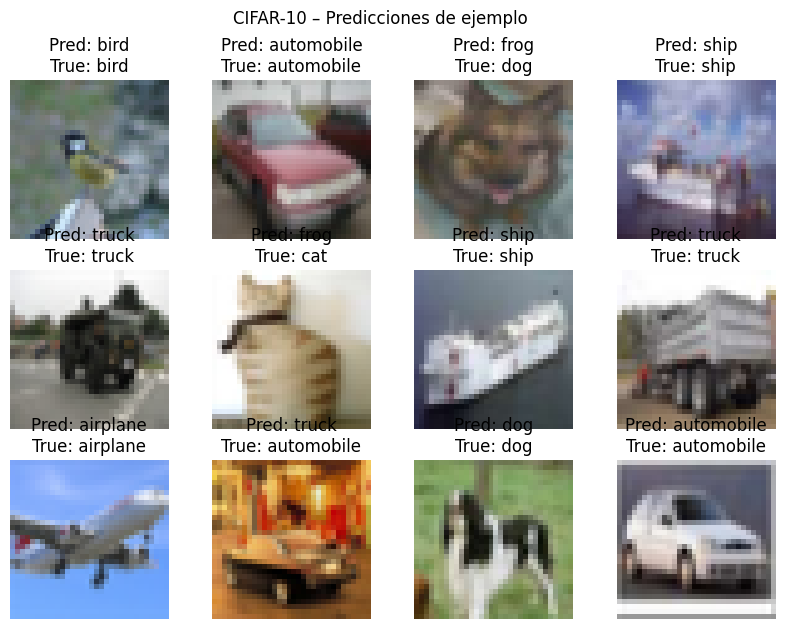

In [19]:
# 11) PREDICCIONES DE EJEMPLO
idx = np.random.choice(len(x_test), 12, replace=False)
imgs = x_test[idx]
pred = y_pred[idx]
true = y_test[idx]

plt.figure(figsize=(10,7))
for i, (im, p, t) in enumerate(zip(imgs, pred, true), 1):
    plt.subplot(3,4,i); plt.imshow(im); plt.axis("off")
    plt.title(f"Pred: {class_names[p]}\nTrue: {class_names[t]}")
plt.suptitle("CIFAR-10 – Predicciones de ejemplo")
plt.show()

Casos correctos (modelo acertó):

Bird → Pred: bird ✅

Automobile → Pred: automobile ✅

Ship → Pred: ship ✅

Truck → Pred: truck ✅

Cat → Pred: cat ✅

Airplane → Pred: airplane ✅

Dog → Pred: dog ✅

Automobile → Pred: automobile ✅

Aquí vemos que el modelo detecta muy bien objetos grandes y definidos como automóviles, camiones, aviones y barcos. También acierta en animales claros como perro o gato.

❌ Casos fallidos (modelo confundió):

Dog → Pred: frog (rana)
→ Posiblemente porque el perro es pequeño y la textura/patrones de color se parecen.

Ship → Pred: truck
→ La foto es borrosa, y los patrones rectangulares pueden confundir con un camión.

Automobile → Pred: truck
→ Es un automóvil pero con forma cuadrada (parecido a camión).

📊 Balance general

La mayoría de las predicciones mostradas son correctas (≈ 9/12).

Los errores ocurren principalmente en animales vs animales y en objetos con formas rectangulares similares (ship ↔ truck, automobile ↔ truck).

Esto es consistente con lo que vimos antes en la matriz de confusión:

Los vehículos son más fáciles de distinguir.

Los animales y formas confusas son el mayor desafío.

In [20]:
# Datasets que siempre está disponible: Rock–Paper–Scissors (imágenes reales de manos haciendo piedra, papel o tijera).
# Es liviano, perfecto para practicar CNN + data augmentation + evaluación.
# Clasificación de gestos: Rock–Paper–Scissors (TFDS)
# ============================================
# 0) Imports y versión
# ============================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import itertools

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)

# Para resultados reproducibles (hasta donde GPU lo permite)
SEED = 42
tf.keras.utils.set_random_seed(SEED)

ModuleNotFoundError: No module named 'tensorflow_datasets'

Dataset: rock_paper_scissors (TFDS)
1. ¿De qué trata?

Es un dataset de imágenes para clasificación de gestos de mano en el clásico juego Piedra, Papel o Tijeras (Rock–Paper–Scissors, RPS).
Fue creado originalmente por Laurence Moroney como parte de un tutorial de Machine Learning con imágenes.

Su objetivo es entrenar modelos de visión por computadora (CNNs) para reconocer el gesto de la mano.

2. Variables (features)

Cuando lo cargas en TFDS, obtienes un diccionario con:

image 🖼️

Tipo: tensor de imágenes en color (RGB).

Tamaño original: 300x300 píxeles (se puede reescalar).

Valores de 0 a 255 (pueden normalizarse a 0–1).

label

Tipo: entero (int64).

Clases (0–2):

0 = rock (piedra)

1 = paper (papel)

2 = scissors (tijeras)

3. Tamaño

~2,892 imágenes en total.

Entrenamiento: 2,520 imágenes.

Prueba: 372 imágenes.

In [ ]:
# ============================================
# 1) Carga del dataset desde Internet (TFDS)
#    rock_paper_scissors con splits ya definidos
# ============================================
# as_supervised=True -> (imagen, etiqueta)
(ds_train, ds_test), ds_info = tfds.load(
    "rock_paper_scissors",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features["label"].names  # ['rock', 'paper', 'scissors']
num_classes = len(class_names)
print("Clases:", class_names, " | num_classes:", num_classes)

In [ ]:
# 2) Preprocesamiento: resize + normalización
# ============================================
IMG_SIZE = (128, 128)
BATCH    = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    # Convertir a float y normalizar [0,1]
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_test  = ds_test.map(preprocess,  num_parallel_calls=AUTOTUNE)

# Crear validación desde train (80/20)
train_size = int(0.8 * ds_info.splits["train"].num_examples)
ds_train_full = ds_train.shuffle(2048, seed=SEED, reshuffle_each_iteration=False)
ds_train = ds_train_full.take(train_size)
ds_val   = ds_train_full.skip(train_size)

# Data augmentation SOLO en entrenamiento
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="augment")

def augment_fn(image, label):
    return augment(image, training=True), label

ds_train = ds_train.map(augment_fn, num_parallel_calls=AUTOTUNE)

# Batching + prefetch
ds_train = ds_train.batch(BATCH).prefetch(AUTOTUNE)
ds_val   = ds_val.batch(BATCH).prefetch(AUTOTUNE)
ds_test  = ds_test.batch(BATCH).prefetch(AUTOTUNE)

In [ ]:
# 3) Visualización rápida de muestras
# ============================================
def show_batch(dataset, n=9):
    images, labels = next(iter(dataset))
    plt.figure(figsize=(10,10))
    for i in range(min(n, images.shape[0])):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")
    plt.suptitle("Ejemplos (train/augmented)")
    plt.show()

show_batch(ds_train)

In [ ]:
# ============================================
# 4) Definir la CNN
#    - Bloques Conv2D + ReLU + MaxPool
#    - Regularización con Dropout
# ============================================
model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
], name="cnn_rps")

model.summary()

In [ ]:
# ============================================
# 5) Compilar + entrenar con EarlyStopping
# ============================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=25,
    callbacks=[early],
    verbose=1
)

In [ ]:
# ============================================
# 6) Curvas de entrenamiento
# ============================================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Época"); plt.ylabel("Pérdida"); plt.title("Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Época"); plt.ylabel("Accuracy"); plt.title("Accuracy")
plt.legend()
plt.show()

In [ ]:
# 7) Evaluación en test + matriz de confusión
# ============================================
test_loss, test_acc = model.evaluate(ds_test, verbose=0)
print(f"Accuracy en test: {test_acc:.4f} | Pérdida: {test_loss:.4f}")

# Obtener predicciones e y_true para la CM
y_true = []
y_prob = []
for x, y in ds_test:
    y_true.append(y.numpy())
    y_prob.append(model.predict(x, verbose=0))
y_true = np.concatenate(y_true)
y_pred = np.argmax(np.concatenate(y_prob, axis=0), axis=1)

cm = confusion_matrix(y_true, y_pred)

# Dibujar matriz de confusión
def plot_cm(cm, classes):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de confusión')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('Real'); plt.xlabel('Predicha')
    plt.tight_layout()
    plt.show()

plot_cm(cm, class_names)
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

In [ ]:
# 8) Predicciones de ejemplo
# ============================================
def show_predictions(dataset, k=9):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(10,10))
    for i in range(min(k, images.shape[0])):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[preds[i]]}\nReal: {class_names[int(labels[i].numpy())]}")
        plt.axis("off")
    plt.suptitle("Predicciones de ejemplo (test)")
    plt.show()

show_predictions(ds_test)